# 5. Field data: plane waves at the Gräfenberg array

A complete, working example to start from: we beamform one day of recordings of the Gräfenberg array in Germany, the day of the 2011 Tohoku earthquake, and track the direction and speed of the incoming waves over the day. To use it for your own data, change the network, stations, times and frequencies in the first cells. New compared to the synthetic examples:

- **plane waves**: we test slowness vectors instead of source positions,
- **field data**, downloaded and prepared with [obspy](https://docs.obspy.org) (needs an internet connection),
- **many time windows** at once.

## 1. Data and geometry

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth
from obspy.signal.util import util_geo_km

# download one day of Gräfenberg array data, and station metadata
client = Client("BGR")
t1 = UTCDateTime("2011-03-11T00:00:00")
t2 = UTCDateTime("2011-03-12T00:00:00")
st_orig = client.get_waveforms("GR", "GR*", "*", "LHZ", t1, t2)
inv = client.get_stations(
    network="GR", station="GR*", location="*", channel="LHZ", starttime=t1, endtime=t2, level="response"
)
st_orig.remove_response(inventory=inv)
print(st_orig)

14 Trace(s) in Stream:
GR.GRA1..LHZ | 2011-03-10T23:59:59.640000Z - 2011-03-11T23:59:59.640000Z | 1.0 Hz, 86401 samples
GR.GRA2..LHZ | 2011-03-11T00:00:00.039999Z - 2011-03-11T23:59:59.039999Z | 1.0 Hz, 86400 samples
GR.GRA3..LHZ | 2011-03-10T23:59:59.349999Z - 2011-03-11T18:59:18.349999Z | 1.0 Hz, 68360 samples
GR.GRA4..LHZ | 2011-03-10T23:59:59.640000Z - 2011-03-11T23:59:59.640000Z | 1.0 Hz, 86401 samples
GR.GRB2..LHZ | 2011-03-10T23:59:59.640000Z - 2011-03-11T23:59:59.640000Z | 1.0 Hz, 86401 samples
GR.GRB3..LHZ | 2011-03-10T23:59:59.640000Z - 2011-03-11T23:59:59.640000Z | 1.0 Hz, 86401 samples
GR.GRB4..LHZ | 2011-03-10T23:59:59.634999Z - 2011-03-11T06:23:28.634999Z | 1.0 Hz, 23010 samples
GR.GRB4..LHZ | 2011-03-11T06:29:25.634999Z - 2011-03-11T18:05:14.634999Z | 1.0 Hz, 41750 samples
GR.GRB4..LHZ | 2011-03-11T18:12:49.634999Z - 2011-03-11T23:59:59.634999Z | 1.0 Hz, 20831 samples
GR.GRB5..LHZ | 2011-03-10T23:59:59.400000Z - 2011-03-11T23:59:59.400000Z | 1.0 Hz, 86401 samples
GR.GRC1

[None,
 Text(0.5, 1.0, 'Gräfenberg array'),
 Text(0.5, 0, 'x [km]'),
 Text(0, 0.5, 'y [km]')]

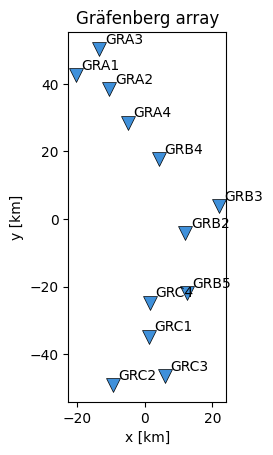

In [2]:
# pre-process seismograms for reasonably stable results
st = st_orig.copy()
st.detrend("demean")
st.detrend("linear")
st.filter("highpass", freq=0.01, zerophase=True)
st.taper(max_percentage=0.01, type="hann")

# force all traces to have the same length; zeros are not an issue for beamforming
st.merge(fill_value=0)
st.trim(t1, t2, pad=True, fill_value=0)
waveforms = np.array([tr.data for tr in st])
sampling_rate = st[0].stats.sampling_rate

# station coordinates in the same order as the traces, in km relative to the array centre
station_names = [tr.stats.station for tr in st]
lonlat = np.array(
    [
        next((sta.longitude, sta.latitude) for net in inv for sta in net if sta.code == name)
        for name in station_names
    ]
)
array_centre = lonlat.mean(axis=0)
stations = np.array([util_geo_km(*array_centre, lon, lat) for lon, lat in lonlat])

fig, ax = plt.subplots()
ax.scatter(*stations.T, marker="v", s=100, c="#3f90da", ec="k", lw=0.5)
for name, (x, y) in zip(station_names, stations):
    ax.annotate(name, (x, y), xytext=(4, 4), textcoords="offset points")
ax.set(aspect="equal", title="Gräfenberg array", xlabel="x [km]", ylabel="y [km]")

## 2. Slowness grid

A plane wave with slowness vector $\mathbf{u}$ reaches sensor $j$ at $t_j = -\mathbf{u} \cdot (\mathbf{r}_j - \mathbf{r}_\mathrm{ref})$, relative to the centre of the array. $\mathbf{u} = |\mathbf{u}|\,(\sin\theta, \cos\theta)$ points towards the back-azimuth $\theta$, the direction of the source. We test back-azimuths every 2° and slownesses from 0 to 0.5 s/km.

9000 slowness vectors


[None,
 Text(0.5, 0, '$u_x$ (east) [s/km]'),
 Text(0, 0.5, '$u_y$ (north) [s/km]'),
 Text(0.5, 1.0, 'slowness grid')]

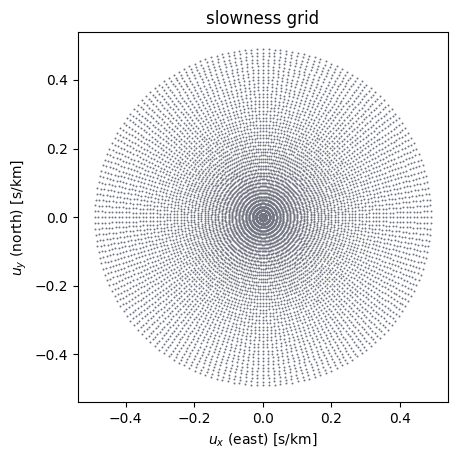

In [3]:
backazimuths = np.deg2rad(np.arange(0, 360, 2))
slownesses = np.arange(0, 0.5, 0.01)
baz_grid, slow_grid = np.meshgrid(backazimuths, slownesses, indexing="ij")
slowness_vectors = np.stack([np.sin(baz_grid) * slow_grid, np.cos(baz_grid) * slow_grid], axis=-1).reshape(
    -1, 2
)
print(f"{len(slowness_vectors)} slowness vectors")

fig, ax = plt.subplots()
ax.scatter(*slowness_vectors.T, s=2, c="#717581", lw=0)
ax.set(aspect="equal", xlabel="$u_x$ (east) [s/km]", ylabel="$u_y$ (north) [s/km]", title="slowness grid")

## 3. Beamforming in time windows

We cut the day into 10-minute windows and compute the spectra of all windows (shape: windows, sensors, frequencies). The steering vectors are the same for every window, so we compute them once. Then, for each window: $K$ without the auto-correlations, and $\mathbf{s}^H K\, \mathbf{s}$ as in notebook 2. We divide the beampower by its largest possible value, $(n_\text{sensors} - 1)$ times the recorded energy: a coherence (notebook 4), which we can compare between windows.

In [4]:
window_length = 600  # s
n_samples = int(window_length * sampling_rate)
n_windows = waveforms.shape[1] // n_samples
windows = waveforms[:, : n_windows * n_samples].reshape(len(stations), n_windows, n_samples)
windows = windows.transpose(1, 0, 2)  # (n_windows, n_sensors, n_samples)
window_starts = np.arange(n_windows) * window_length

# spectra of all windows, limited to the secondary microseism band
# (the data are sampled at 1 Hz, so frequencies are limited to 0.5 Hz anyway)
fmin, fmax = 0.1, 0.3
freqs = np.fft.rfftfreq(n_samples, 1 / sampling_rate)
band = (freqs > fmin) & (freqs < fmax)
spectra = np.fft.rfft(windows * np.hanning(n_samples), axis=-1)[:, :, band]
omega = 2 * np.pi * freqs[band]
print(f"spectra: {spectra.shape} (windows, sensors, frequencies)")

# steering vectors of all slowness vectors, (frequencies, slowness vectors, sensors)
traveltimes = -slowness_vectors @ stations.T
s = np.exp(-1j * omega[:, None, None] * traveltimes[None, :, :]).astype(np.complex64)

n_sensors = len(stations)
coherence = np.zeros((n_windows, len(slowness_vectors)))
for m in range(n_windows):
    d = spectra[m].T.astype(np.complex64)  # (frequencies, sensors)
    K = d[:, :, None] * d[:, None, :].conj()  # cross-spectral density matrix of this window
    K[:, np.arange(n_sensors), np.arange(n_sensors)] = 0  # without the auto-correlations
    beampower = np.sum((s.conj() @ K) * s, axis=(0, 2)).real  # s^H K s, summed over frequencies
    coherence[m] = beampower / ((n_sensors - 1) * np.sum(np.abs(d) ** 2))
print(f"coherence: {coherence.shape} (windows, slowness vectors)")

spectra: (144, 12, 119) (windows, sensors, frequencies)


coherence: (144, 9000) (windows, slowness vectors)


## 4. Results

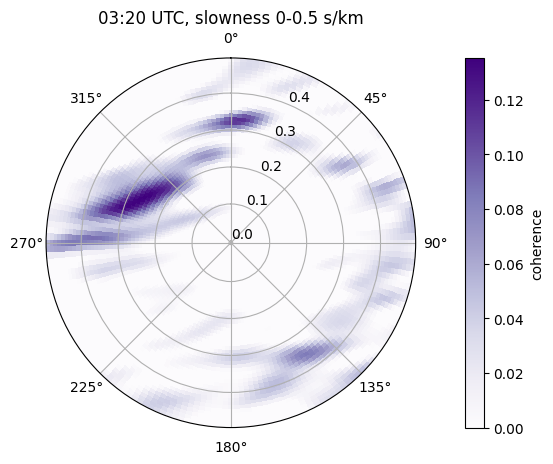

In [5]:
# beamforming result of a single window, in polar coordinates
window_idx = 20
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.set(theta_zero_location="N", theta_direction=-1)
pcm = ax.pcolormesh(
    backazimuths, slownesses, coherence[window_idx].reshape(len(backazimuths), len(slownesses)).T,
    cmap="Purples", vmin=0, shading="nearest",
)  # fmt: skip
ax.set_title(f"{(t1 + window_starts[window_idx]).strftime('%H:%M')} UTC, slowness 0-0.5 s/km")
fig.colorbar(pcm, label="coherence", pad=0.1)

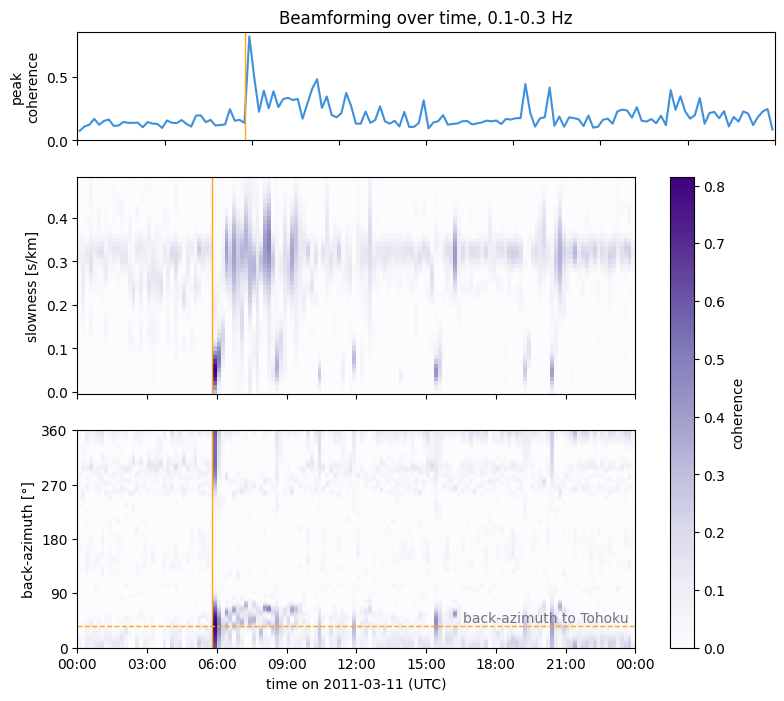

In [6]:
# best-fitting back-azimuth and slowness in each window
best = np.argmax(coherence, axis=1)
best_baz_idx, best_slow_idx = np.unravel_index(best, (len(backazimuths), len(slownesses)))
coherence_grid = coherence.reshape(n_windows, len(backazimuths), len(slownesses))
# slices through the maximum: over slowness at the best back-azimuth, and vice versa
slowness_slices = coherence_grid[np.arange(n_windows), best_baz_idx, :]
backazimuth_slices = coherence_grid[np.arange(n_windows), :, best_slow_idx]
peak_coherence = coherence[np.arange(n_windows), best]

times_plot = [(t1 + t + window_length / 2).datetime for t in window_starts]

# back-azimuth from Gräfenberg to the Tohoku earthquake
event_time = UTCDateTime("2011-03-11T05:46:23")
_, _, event_baz = gps2dist_azimuth(38.322, 142.369, array_centre[1], array_centre[0])

fig, axs = plt.subplots(3, sharex=True, figsize=(9, 8), height_ratios=[1, 2, 2])
axs[0].plot(times_plot, peak_coherence, c="#3f90da", lw=1.5)
axs[0].set(ylabel="peak\ncoherence", ylim=(0, None), title="Beamforming over time, 0.1-0.3 Hz")
pcm = axs[1].pcolormesh(times_plot, slownesses, slowness_slices.T, cmap="Purples", vmin=0, shading="nearest")
axs[1].set(ylabel="slowness [s/km]")
axs[2].pcolormesh(
    times_plot, np.rad2deg(backazimuths), backazimuth_slices.T, cmap="Purples", vmin=0, shading="nearest"
)
axs[2].axhline(event_baz, color="#ffa90e", lw=1, ls="--")
axs[2].text(times_plot[-1], event_baz, "back-azimuth to Tohoku ", ha="right", va="bottom", color="#717581")
axs[2].set(ylabel="back-azimuth [°]", ylim=(0, 360), yticks=[0, 90, 180, 270, 360])
for ax in axs:
    ax.axvline(event_time.datetime, color="#ffa90e", lw=1)
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axs[2].set_xlabel(f"time on {t1.strftime('%Y-%m-%d')} (UTC)")
fig.colorbar(pcm, ax=axs[1:], label="coherence")

The orange line marks the time of the earthquake, the dashed line its direction.

- **Before the earthquake**, the array records ocean-generated noise (the secondary microseism) from about 300°, the North Atlantic, at about 0.3 s/km (surface waves at ~3.3 km/s). Only 10–20 % of the energy is coherent.
- **About 12 minutes after the earthquake**, its first waves arrive from its direction. They come up steeply from the deep Earth and reach all sensors almost at once, so their slowness is close to 0. 80 % of the energy is coherent.
- **For hours afterwards**, surface waves of the earthquake and its aftershocks arrive from the north-east, again at about 0.3 s/km.

Try other frequency bands and window lengths. For MVDR or MUSIC over time, one window per time step is not enough: cut each 10-minute window into shorter ones and average $K$ over them (notebook 4). Notebook 6 locates a source on a map instead, with traveltimes from a velocity model.